#BLOQUE 1: CLONACIÓN DE REPO

In [1]:
import os, getpass, sys

USER_NAME  = "PandoraRiot"
USER_EMAIL = "e.garcia1565@pascualbravo.edu.co"
REPO_NAME  = "breast-cancer-dce-mri-classification"

!git config --global user.name "{USER_NAME}"
!git config --global user.email "{USER_EMAIL}"

token    = getpass.getpass("🔑 PAT: ")
repo_url = f"https://{token}@github.com/{USER_NAME}/{REPO_NAME}.git"

if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone {repo_url}

%cd /content/{REPO_NAME}
sys.path.append(f"/content/{REPO_NAME}")

print("✅ Repo clonado. Archivos disponibles:")
print(os.listdir(f"/content/{REPO_NAME}"))

🔑 PAT: ··········
/content/breast-cancer-dce-mri-classification
✅ Repo clonado. Archivos disponibles:
['BREAST_ROI_TEST (2).csv', '.git', 'BREAST_ROI_TEST (1).csv', 'breast_dataset.py', 'BREAST_ROI_TEST (3).csv', 'BREAST_ROI_TRAIN (1).csv', 'dataset_preparation.ipynb', 'BREAST_ROI_TRAIN (3).csv', 'BREAST_ROI_TRAIN.csv', 'BREAST_ROI_VAL (3).csv', 'BREAST_ROI_VAL.csv', 'BREAST_ROI_VAL (1).csv', 'clasification-roi (1).zip', 'BREAST_ROI_TEST.csv', 'clasification-roi.zip', 'BREAST_ROI_VAL (2).csv', '__pycache__', 'BREAST_ROI_TRAIN (2).csv']


#CARGA DE DATASET Y CSV

In [2]:
from google.colab import files
import zipfile

uploaded = files.upload()  # Sube solo el ZIP

with zipfile.ZipFile("clasification-roi.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("✅ Dataset descomprimido")

Saving clasification-roi.zip to clasification-roi (2).zip
✅ Dataset descomprimido


In [3]:
from google.colab import files

uploaded_csvs = files.upload()  # Sube los 3 CSVs

for filename in uploaded_csvs:
    print(f"✅ CSV cargado: {filename}")

Saving BREAST_ROI_TEST.csv to BREAST_ROI_TEST (4).csv
Saving BREAST_ROI_TRAIN.csv to BREAST_ROI_TRAIN (4).csv
Saving BREAST_ROI_VAL.csv to BREAST_ROI_VAL (4).csv
✅ CSV cargado: BREAST_ROI_TEST (4).csv
✅ CSV cargado: BREAST_ROI_TRAIN (4).csv
✅ CSV cargado: BREAST_ROI_VAL (4).csv


BLOQUE 3 — Configuración de rutas


In [19]:
DATASET_ROOT = "/content/dataset"

TRAIN_CSV = "/content/breast-cancer-dce-mri-classification/BREAST_ROI_TRAIN.csv"
TEST_CSV  = "/content/breast-cancer-dce-mri-classification/BREAST_ROI_TEST.csv"
VAL_CSV   = "/content/breast-cancer-dce-mri-classification/BREAST_ROI_VAL.csv"

In [20]:
import sys
import os

sys.path.append("/content/breast-cancer-dce-mri-classification")

# Verificar que el script esté ahí
print(os.path.exists("/content/breast-cancer-dce-mri-classification/breast_dataset.py"))

True


BLOQUE 4: INICIAR EL DATALOADER

In [21]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'breast-cancer-dce-mri-classification', 'dataset', 'sample_data']


In [22]:
print(os.listdir("/content/breast-cancer-dce-mri-classification"))


['BREAST_ROI_TEST (2).csv', '.git', 'BREAST_ROI_TEST (1).csv', 'BREAST_ROI_TRAIN (4).csv', 'breast_dataset.py', 'BREAST_ROI_TEST (3).csv', 'BREAST_ROI_TRAIN (1).csv', 'dataset_preparation.ipynb', 'BREAST_ROI_TRAIN (3).csv', 'BREAST_ROI_TRAIN.csv', 'BREAST_ROI_VAL (3).csv', 'BREAST_ROI_TEST (4).csv', 'BREAST_ROI_VAL.csv', 'BREAST_ROI_VAL (4).csv', 'BREAST_ROI_VAL (1).csv', 'clasification-roi (1).zip', 'clasification-roi (2).zip', 'BREAST_ROI_TEST.csv', 'clasification-roi.zip', 'BREAST_ROI_VAL (2).csv', '__pycache__', 'BREAST_ROI_TRAIN (2).csv']


In [23]:
%cd /content/breast-cancer-dce-mri-classification
!git pull

import os
print(os.listdir("/content/breast-cancer-dce-mri-classification"))

/content/breast-cancer-dce-mri-classification
Updating 373bb49..a43ba18
error: Your local changes to the following files would be overwritten by merge:
	breast_dataset.py
Please commit your changes or stash them before you merge.
Aborting
['BREAST_ROI_TEST (2).csv', '.git', 'BREAST_ROI_TEST (1).csv', 'BREAST_ROI_TRAIN (4).csv', 'breast_dataset.py', 'BREAST_ROI_TEST (3).csv', 'BREAST_ROI_TRAIN (1).csv', 'dataset_preparation.ipynb', 'BREAST_ROI_TRAIN (3).csv', 'BREAST_ROI_TRAIN.csv', 'BREAST_ROI_VAL (3).csv', 'BREAST_ROI_TEST (4).csv', 'BREAST_ROI_VAL.csv', 'BREAST_ROI_VAL (4).csv', 'BREAST_ROI_VAL (1).csv', 'clasification-roi (1).zip', 'clasification-roi (2).zip', 'BREAST_ROI_TEST.csv', 'clasification-roi.zip', 'BREAST_ROI_VAL (2).csv', '__pycache__', 'BREAST_ROI_TRAIN (2).csv']


In [24]:
import sys
sys.path.append("/content/breast-cancer-dce-mri-classification")

In [25]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'breast-cancer-dce-mri-classification', 'dataset', 'sample_data']


In [26]:
from breast_dataset import BreastLoader

loader = BreastLoader(
    train_csv    = TRAIN_CSV,
    test_csv     = TEST_CSV,
    val_csv      = VAL_CSV,
    dataset_root = DATASET_ROOT,
    batch_size   = 16,
    num_workers  = 2
)


📦 BreastLoader inicializado:
  Train batches : 76
  Test  batches : 26
  Val   batches : 8
  Batch size    : 16
  Imagen shape  : (3, 256, 256) — [pre, early, late]


In [27]:
batch = next(iter(loader.train_loader))

print("Shape del batch :", batch["image"].shape)  # (16, 3, 256, 256)
print("Labels          :", batch["label"])
print("Pacientes       :", batch["patient"][:4])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape del batch : torch.Size([16, 3, 256, 256])
Labels          : tensor([0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1])
Pacientes       : ['BreaDM-Be-1910', 'BreaDM-Ma-2129', 'BreaDM-Ma-2040', 'BreaDM-Ma-2138']


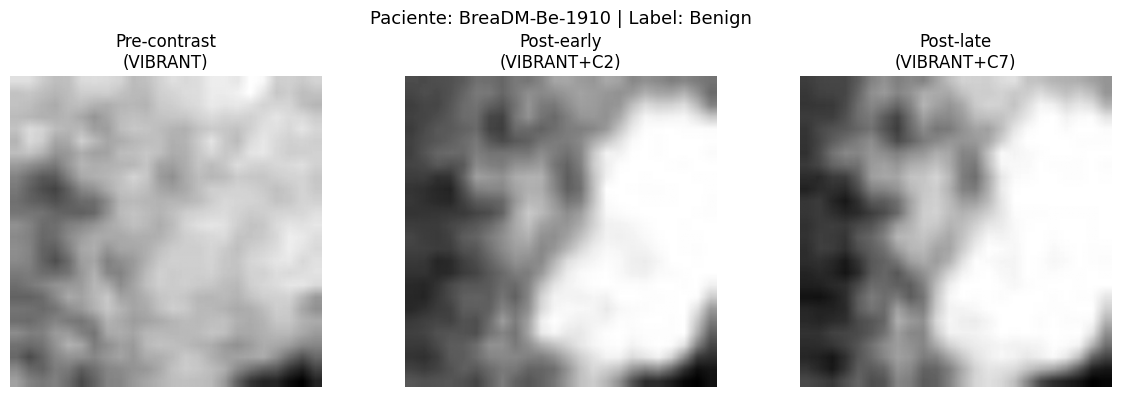

In [28]:
import matplotlib.pyplot as plt

def visualize_sample(batch, idx=0):

    image   = batch["image"][idx]
    label   = batch["label"][idx].item()
    patient = batch["patient"][idx]

    label_name = "Malignant" if label == 1 else "Benign"
    titles     = ["Pre-contrast\n(VIBRANT)",
                  "Post-early\n(VIBRANT+C2)",
                  "Post-late\n(VIBRANT+C7)"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Paciente: {patient} | Label: {label_name}", fontsize=13)

    for i, ax in enumerate(axes):
        ax.imshow(image[i].numpy(), cmap="gray")
        ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_sample(batch, idx=0)

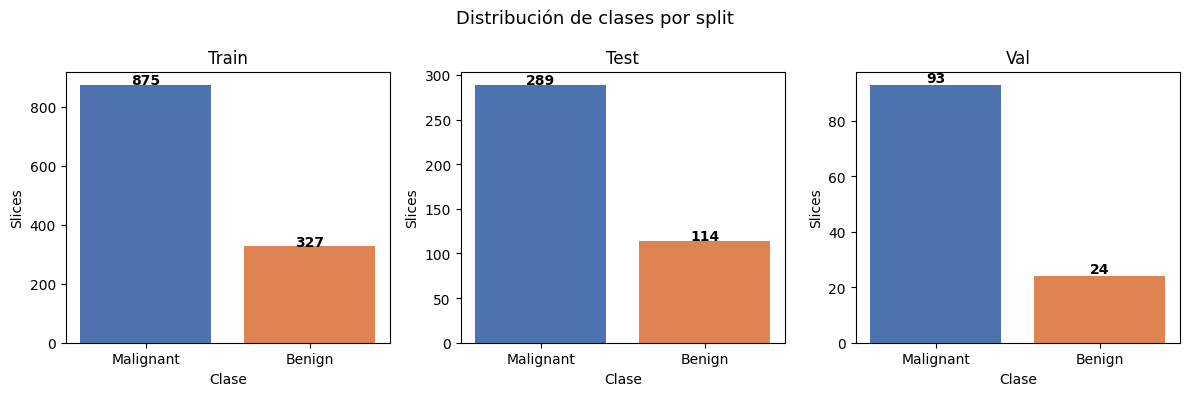

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Distribución de clases por split", fontsize=13)

csvs   = [TRAIN_CSV, TEST_CSV, VAL_CSV]
splits = ["Train", "Test", "Val"]
colors = ["#4C72B0", "#DD8452"]

for ax, csv, split in zip(axes, csvs, splits):
    df     = pd.read_csv(csv)
    counts = df["label"].value_counts()
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(split)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Slices")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [30]:
import os

REPO_PATH = "/content/breast-cancer-dce-mri-classification"

# Archivos basura a eliminar
basura = [
    "BREAST_ROI_TEST (1).csv",
    "BREAST_ROI_TEST (2).csv",
    "BREAST_ROI_TRAIN (1).csv",
    "BREAST_ROI_TRAIN (2).csv",
    "BREAST_ROI_VAL (1).csv",
    "BREAST_ROI_VAL (2).csv",
    "clasification-roi.zip",
    "clasification-roi (1).zip",
]

for archivo in basura:
    ruta = os.path.join(REPO_PATH, archivo)
    if os.path.exists(ruta):
        os.remove(ruta)
        print(f"🗑️  Eliminado: {archivo}")
    else:
        print(f"⚠️  No encontrado: {archivo}")

🗑️  Eliminado: BREAST_ROI_TEST (1).csv
🗑️  Eliminado: BREAST_ROI_TEST (2).csv
🗑️  Eliminado: BREAST_ROI_TRAIN (1).csv
🗑️  Eliminado: BREAST_ROI_TRAIN (2).csv
🗑️  Eliminado: BREAST_ROI_VAL (1).csv
🗑️  Eliminado: BREAST_ROI_VAL (2).csv
🗑️  Eliminado: clasification-roi.zip
🗑️  Eliminado: clasification-roi (1).zip


In [31]:
%cd /content/breast-cancer-dce-mri-classification

!git rm "BREAST_ROI_TEST (1).csv" "BREAST_ROI_TEST (2).csv" \
        "BREAST_ROI_TRAIN (1).csv" "BREAST_ROI_TRAIN (2).csv" \
        "BREAST_ROI_VAL (1).csv" "BREAST_ROI_VAL (2).csv" \
        "clasification-roi.zip" "clasification-roi (1).zip" 2>/dev/null || true

!git add -A
!git commit -m "chore: limpiar archivos duplicados y zips del repositorio"
!git push {repo_url}

print("✅ Repositorio limpio.")

/content/breast-cancer-dce-mri-classification
[main bb790c6] chore: limpiar archivos duplicados y zips del repositorio
 12 files changed, 5210 insertions(+), 3 deletions(-)
 create mode 100644 BREAST_ROI_TEST (3).csv
 create mode 100644 BREAST_ROI_TEST (4).csv
 create mode 100644 BREAST_ROI_TEST.csv
 create mode 100644 BREAST_ROI_TRAIN (3).csv
 create mode 100644 BREAST_ROI_TRAIN (4).csv
 create mode 100644 BREAST_ROI_TRAIN.csv
 create mode 100644 BREAST_ROI_VAL (3).csv
 create mode 100644 BREAST_ROI_VAL (4).csv
 create mode 100644 BREAST_ROI_VAL.csv
 create mode 100644 __pycache__/breast_dataset.cpython-312.pyc
 create mode 100644 clasification-roi (2).zip
To https://github.com/PandoraRiot/breast-cancer-dce-mri-classification.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/PandoraRiot/breast-cancer-dce-mri-classification.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote cou

In [32]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

NOTEBOOK_NAME = "dataloader_test.ipynb"

shutil.copy(
    f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}",
    f"/content/breast-cancer-dce-mri-classification/{NOTEBOOK_NAME}"
)

!git add {NOTEBOOK_NAME}
!git commit -m "feat: notebook de pruebas y visualización del dataloader DCE-MRI - Versión 1"
!git push {repo_url}

print("✅ Notebook subido a GitHub.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[main f40ce3e] feat: notebook de pruebas y visualización del dataloader DCE-MRI - Versión 1
 1 file changed, 1 insertion(+)
 create mode 100644 dataloader_test.ipynb
To https://github.com/PandoraRiot/breast-cancer-dce-mri-classification.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/PandoraRiot/breast-cancer-dce-mri-classification.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
✅ Notebook subido a GitHub.
